# Dielectrics: a quartz tube in a perturbation cavity

Cavities in `cavsim2d` are vacuum by default. `cav.add_dielectric(...)` fills part
of one with a **dielectric** — a ceramic window, a beam-pipe liner, an
absorber ring — and the eigenmode solver then solves the loaded problem. This
notebook keeps the sample lossless; for a lossy one see
[the dielectric-loss example](dielectric_loss.ipynb).

The example here is a **perturbation chamber**: a small pillbox with a 5 mm axial
aperture, used to measure material properties by inserting a sample and reading
the frequency shift. The sample is a fused-quartz tube that lines the aperture
and runs the full height of the chamber.

This notebook is live: every number and figure below is produced by running
`cavsim2d`.

We will

1. build the empty chamber and add the tube,
2. check that the thin wall is meshed and that the interface is conformal,
3. measure what the tube does to two modes — and see it move one by 167 MHz and
   the other by 28 kHz,
4. verify the shift against first-order cavity-perturbation theory.

In [1]:
import os
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import jn_zeros, j0, j1

from cavsim2d import Pillbox
from cavsim2d.utils.style import apply_style, WARM

apply_style()          # the house publication style
QUARTZ_C = WARM[7]     # gold - the quartz, everywhere it is drawn

C0 = 299792458.0
trapz = getattr(np, 'trapezoid', np.trapz)      # numpy renamed trapz -> trapezoid
WORK = tempfile.mkdtemp()                       # docs runs leave nothing behind

## 1. The chamber

A one-cell `Pillbox` with a short aperture stub at each end. The dims are
`[L, Req, Ri, S, L_bp]` in mm, so a 75 mm-diameter, 20 mm-high chamber with a
5 mm-diameter hole and 5 mm stubs is:

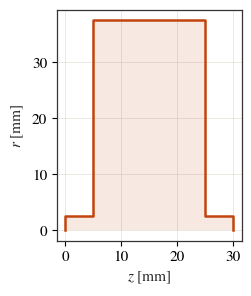

<Axes: xlabel='$z$ [mm]', ylabel='$r$ [mm]'>

In [2]:
CHAMBER = [20.0, 37.5, 2.5, 0.0, 5.0]      # L, Req, Ri, S, L_bp  [mm]

EPS_QUARTZ = 4.5478        # relative permittivity of the tube
TUBE_R = (2.0, 2.5)        # wall inner/outer radius [mm] - 5 mm OD, 0.5 mm wall
TUBE_MAXH = 0.15           # local mesh size inside the wall [mm]


def build(name, eps_r=None):
    """The chamber, optionally loaded with the quartz tube."""
    cav = Pillbox(1, CHAMBER, beampipe='both')
    cav.set_workspace(os.path.join(WORK, name))
    if eps_r is not None:
        # z spans everything and is clipped to the cavity, so this simply means
        # "the full length". Lengths are in mm, like every other cavity dimension.
        cav.add_dielectric('quartz', eps_r, z=(-1e4, 1e4), r=TUBE_R, maxh=TUBE_MAXH)
    return cav


build('preview').plot('geometry')

## 2. Adding the tube

One call declares the region and its permittivity:

```python
cav.add_dielectric('quartz', 4.5478, z=(-1e4, 1e4), r=(2.0, 2.5), maxh=0.15)
```

The region is an axisymmetric **rectangular ring** in the `(z, r)` meridian plane
— an annular cylinder in 3D. `maxh` sets the element size *inside* the region,
which a thin wall needs: 0.5 mm of quartz in a 75 mm chamber would otherwise be
crossed by a single element.

The mesh gains a material named `quartz` alongside the background `Domain`, and
the vacuum/quartz interface becomes its own boundary, `IF_quartz`. That interface
carries **no** boundary condition — it is not `PEC` — and the mesh is glued so it
is *conformal*. Both matter: a non-conformal interface would leave the
sub-domains electrically disconnected and the solver would return spurious modes
of the isolated pieces. `Profile.mesh()` checks this and raises, so the zero
below is enforced, not hoped for.

In [3]:
from ngsolve import VOL
from cavsim2d.solvers.NGSolve.eigen_ngsolve import NGSolveMEVP

mesh = NGSolveMEVP()._build_mesh(build('meshcheck', EPS_QUARTZ), 3e-3, 1)
print('materials :', mesh.GetMaterials())
print('boundaries:', sorted(set(mesh.GetBoundaries())))
print('elements  :', mesh.ne)

pts = np.array([mesh[v].point for v in mesh.vertices])
_, counts = np.unique(np.round(pts, 12), axis=0, return_counts=True)
print('duplicated interface nodes:', int((counts > 1).sum()), '(0 = conformal)')

materials : ('quartz', 'Domain', 'Domain')
boundaries: ['AXI', 'IF_quartz', 'PEC', 'PMC']
elements  : 3087
duplicated interface nodes: 0 (0 = conformal)


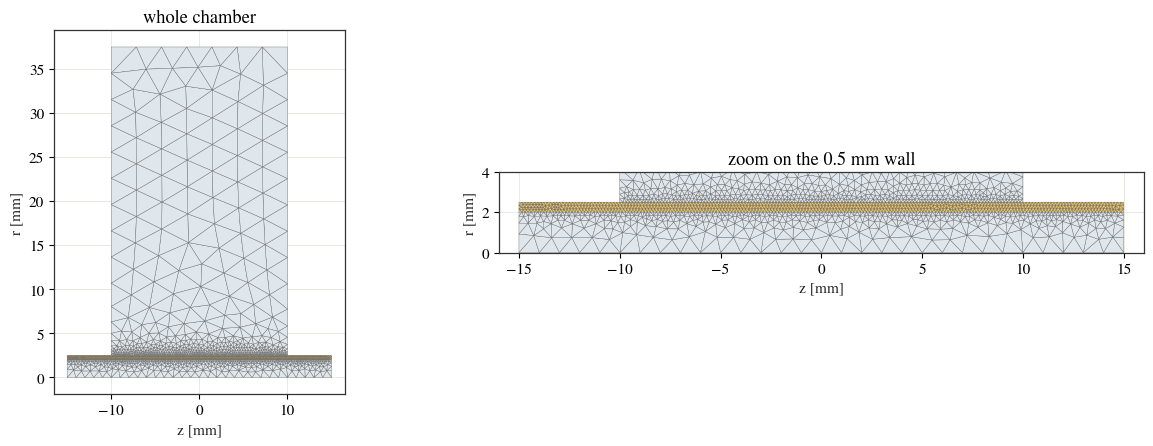

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, zoom, title in [(axes[0], None, 'whole chamber'),
                        (axes[1], ((-16, 16), (0, 4)), 'zoom on the 0.5 mm wall')]:
    for el in mesh.Elements(VOL):
        v = np.array([mesh[k].point for k in el.vertices]) * 1e3        # -> mm
        ax.fill(v[:, 0], v[:, 1], lw=0.25, edgecolor='0.35',
                facecolor=QUARTZ_C if el.mat == 'quartz' else '#dfe6ec')
    ax.set_xlabel('z [mm]'); ax.set_ylabel('r [mm]')
    ax.set_aspect('equal'); ax.set_title(title)
    if zoom:
        ax.set_xlim(zoom[0]); ax.set_ylim(zoom[1])
plt.tight_layout(); plt.show()

## 3. What the tube does to the spectrum

The chamber is used on two modes, TM$_{020}$ and TM$_{210}$. Each solved mode is
matched to its nearest analytic *empty*-pillbox partner so we can pick the two by
name rather than by index.

In [5]:
def f_tm(m, n, p, R, L):
    """Analytic TM_mnp frequency [MHz] of an empty pillbox; R, L in mm."""
    return C0 / (2 * np.pi) * np.hypot(jn_zeros(m, n)[n - 1] / (R * 1e-3),
                                       p * np.pi / (L * 1e-3)) * 1e-6


R_CH, L_CH = CHAMBER[1], CHAMBER[0]
F_TM020, F_TM210 = f_tm(0, 2, 0, R_CH, L_CH), f_tm(2, 1, 0, R_CH, L_CH)


def solve(cav):
    """Solve both families; return (f_TM020, f_TM210) in MHz plus the table."""
    cav.eigenmode.run(polarisation=['monopole', 'quadrupole'], n_modes=4,
                      mesh_config={'h': 3, 'p': 3})
    df = cav.eigenmode.qois_df
    out = []
    for m, f_ref in [(0, F_TM020), (2, F_TM210)]:
        fam = df[df['m'] == m]
        out.append(fam.iloc[(fam['freq [MHz]'] - f_ref).abs().argmin()])
    return np.array([r['freq [MHz]'] for r in out]), out


cav_empty = build('empty')
cav_loaded = build('loaded', EPS_QUARTZ)
f_empty, _ = solve(cav_empty)
f_loaded, rows_loaded = solve(cav_loaded)

pd.DataFrame({'analytic, empty [MHz]': [F_TM020, F_TM210],
              'empty [MHz]': f_empty,
              'with quartz [MHz]': f_loaded,
              'shift [MHz]': f_loaded - f_empty,
              'shift [%]': 100 * (f_loaded - f_empty) / f_empty},
             index=['TM020', 'TM210']).round(4)

,"analytic, empty [MHz]",empty [MHz],with quartz [MHz],shift [MHz],shift [%]
TM020,7023.5195,7029.1778,6862.3652,-166.8126,-2.3731
TM210,6534.3538,6534.3189,6534.2902,-0.0287,-0.0004


One 0.5 mm-thick ring moves TM$_{020}$ by well over a hundred MHz and TM$_{210}$
by a few tens of **kHz** — nearly four orders of magnitude apart.

That is not a quirk of the solver; it is where the two modes keep their field.

## 4. Why: the tube sits on one mode and not the other

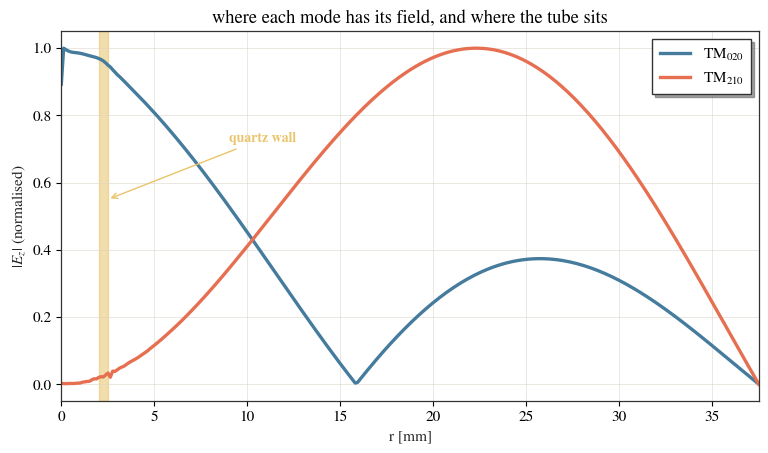

In [6]:
def radial_profile(cav, row, n=300):
    """|E_z| envelope along r at the mid-plane, normalised to its peak."""
    mode, pol = int(row['mode']), row['polarisation']
    gfu_E, _ = cav.get_fields(mode=mode, pol=pol)
    u, _ = gfu_E[mode].components
    msh = gfu_E[mode].space.mesh
    r = np.linspace(1e-4, R_CH * (1 - 1e-4), n)
    v = []
    for ri in r:
        try:
            v.append(u(msh(0.0, ri * 1e-3))[0])
        except Exception:
            v.append(np.nan)
    v = np.abs(np.array(v, dtype=float))
    return r, v / np.nanmax(v)


fig, ax = plt.subplots(figsize=(9, 4.8))
for row, name, col in zip(rows_loaded, ['TM$_{020}$', 'TM$_{210}$'],
                          [WARM[0], WARM[5]]):
    r, v = radial_profile(cav_loaded, row)
    ax.plot(r, v, lw=2.4, color=col, label=name)

ax.axvspan(*TUBE_R, color=QUARTZ_C, alpha=0.55, zorder=0)
ax.annotate('quartz wall', xy=(TUBE_R[1], 0.55), xytext=(9, 0.72),
            color=QUARTZ_C, fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=QUARTZ_C))
ax.set_xlabel('r [mm]'); ax.set_ylabel(r'$|E_z|$ (normalised)')
ax.set_xlim(0, R_CH); ax.legend()
ax.set_title('where each mode has its field, and where the tube sits')
plt.show()

The shaded strip is the entire tube. TM$_{020}$ is at ~100 % of its peak there
($J_0(0) = 1$ on the axis); TM$_{210}$ is at essentially zero, because a
quadrupole field goes as $r^2$ near the axis. A perturbation only shifts a mode
in proportion to the field it actually sees.

This is exactly what makes the geometry useful for measurement: TM$_{210}$ is an
almost sample-independent reference sitting next to a sample-sensitive TM$_{020}$.

## 5. Does it agree with perturbation theory?

For a thin sample, first-order cavity-perturbation theory gives

$$\frac{\Delta f}{f} \;=\; -\,\frac{\varepsilon_r - 1}{2}\,
   \frac{\int_{\rm sample} |E|^2\,{\rm d}V}{\int_V |E|^2\,{\rm d}V}.$$

$E_z$ is *tangential* to the tube wall, so $E$ (not $D$) is continuous across it
and this plain form applies. Sweeping $\varepsilon_r$ tests the solver against it.

In [7]:
def slater_shift(eps_r):
    """First-order predicted fractional shift of TM020 from the tube."""
    R = R_CH * 1e-3
    x02 = jn_zeros(0, 2)[1]
    rr = np.linspace(TUBE_R[0] * 1e-3, TUBE_R[1] * 1e-3, 200)
    num = trapz(j0(x02 * rr / R) ** 2 * rr, rr)     # weight over the tube annulus
    den = R ** 2 * j1(x02) ** 2 / 2                 # over the full disc
    return -(eps_r - 1) / 2 * num / den


scan = [1.0, 2.0, 3.0, 3.8, EPS_QUARTZ]
solved = {e: solve(build('eps_%s' % str(e).replace('.', 'p'), e))[0] for e in scan}

# Reference the shifts to the SAME mesh at eps_r = 1, not to the unloaded run:
# the region splits the mesh and refines it locally, so comparing against the
# coarse empty mesh would fold a ~0.2 MHz discretisation difference into every
# row. Against eps_r = 1 the only thing that changes is the permittivity.
f_ref = solved[1.0]
scan_df = pd.DataFrame(
    [{'eps_r': e, 'TM020 [MHz]': solved[e][0], 'TM210 [MHz]': solved[e][1],
      'TM020 shift [MHz]': solved[e][0] - f_ref[0],
      'predicted [MHz]': slater_shift(e) * f_ref[0]} for e in scan]
).set_index('eps_r')
scan_df.round(4)

,TM020 [MHz],TM210 [MHz],TM020 shift [MHz],predicted [MHz]
eps_r,,,,
1.0000,7029.4036,6534.3151,0.0000,-0.0000
2.0000,6983.4773,6534.3082,-45.9263,-45.9302
3.0000,6936.6734,6534.3010,-92.7301,-91.8605
3.8000,6898.5361,6534.2953,-130.8675,-128.6047
4.5478,6862.3656,6534.2904,-167.0379,-162.9513


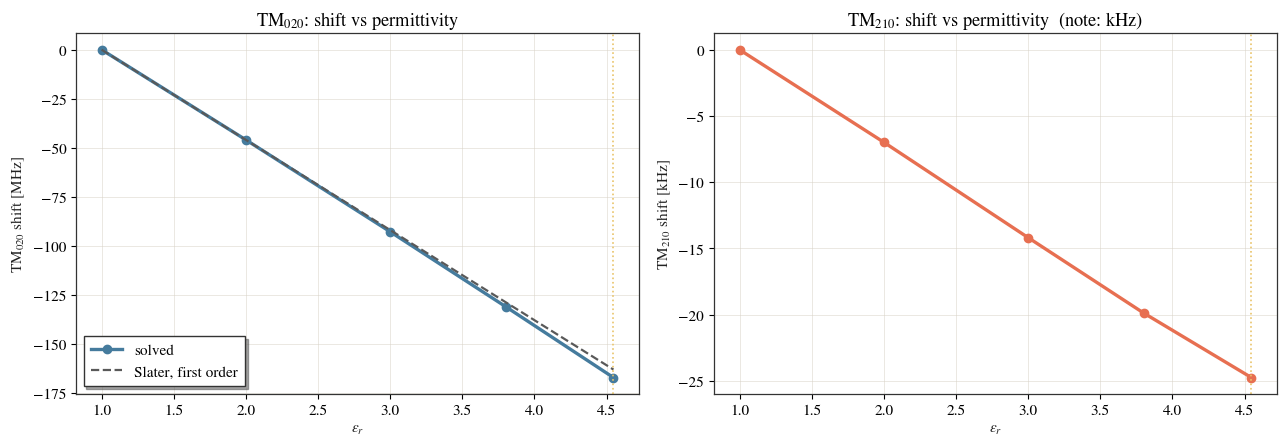

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
e = scan_df.index.to_numpy()

axes[0].plot(e, scan_df['TM020 shift [MHz]'], 'o-', color=WARM[0], lw=2.4,
             label='solved')
axes[0].plot(e, scan_df['predicted [MHz]'], '--', color='0.35', lw=1.6,
             label='Slater, first order')
axes[0].set_ylabel('TM$_{020}$ shift [MHz]'); axes[0].legend()
axes[0].set_title('TM$_{020}$: shift vs permittivity')

axes[1].plot(e, (scan_df['TM210 [MHz]'] - f_ref[1]) * 1e3, 'o-',
             color=WARM[5], lw=2.4)
axes[1].set_ylabel('TM$_{210}$ shift [kHz]')
axes[1].set_title('TM$_{210}$: shift vs permittivity  (note: kHz)')

for a in axes:
    a.set_xlabel(r'$\varepsilon_r$')
    a.axvline(EPS_QUARTZ, color=QUARTZ_C, lw=1.2, ls=':')
plt.tight_layout(); plt.show()

The solved shift follows the first-order line closely at small $\varepsilon_r$ and
falls a little below it as the tube strengthens — exactly as expected, since
perturbation theory assumes the mode shape does not change, while a strong tube
concentrates field into itself. The agreement at the weak end is the check that
the dielectric is being solved correctly.

Read the other way, this is the measurement principle: the TM$_{020}$ shift is a
monotonic, near-linear function of $\varepsilon_r$, so measuring the shift
determines the sample's permittivity.

## Extra QOI: the peak field inside the dielectric

$E$ is discontinuous across the interface, so the wall-sampled `Epk` cannot see
the field *inside* the sample — the one that matters for breakdown. Each region
gets its own entry:

In [9]:
# rows_loaded[0] is the TM020 row picked above. (cav.eigenmode.qois would give
# the default mode of interest instead - the monopole fundamental, TM010.)
q = rows_loaded[0]
print('mode: TM020')
for k in ['freq [MHz]', 'Q []', 'R/Q [Ohm]', 'U [J]',
          'Epk [MV/m]', 'Epk_quartz [MV/m]']:
    print('  %-20s %.6g' % (k, q[k]))

mode: TM020
  freq [MHz]           6862.37
  Q []                 16879.7
  R/Q [Ohm]            100.887
  U [J]                2.78163e-11
  Epk [MV/m]           0.00370244
  Epk_quartz [MV/m]    0.00331698


## Limits

- **No loss tangent was declared here**, so the `Q` above is wall loss alone.
  That is the right model for this sample — fused quartz has
  $\tan\delta \sim 10^{-4}$ and a small filling factor, so the dielectric barely
  contributes — but a genuinely lossy sample needs
  `add_dielectric(..., tan_delta=...)`; see
  [the dielectric-loss example](dielectric_loss.ipynb). `mu_r` is still
  *rejected*, not ignored.
- **Eigenmode only.** `wakefield` and `multipacting` raise on a cavity with
  dielectric regions rather than returning a vacuum answer for it.
- **Native geometry only.** A cavity meshed from an imported `.geo` file cannot
  carry regions, because gmsh writes a single physical surface and the STEP
  round-trip drops surface names. Every built-in model has a native `profile()`.
- Regions are cut **in order**, so where two overlap the one added first wins.

See :doc:`../../eigenmode` for the configuration reference, including the
`materials` key that overrides a region's $\varepsilon_r$ per run.